[2026-07-29 23:00:39] [info     ] 计算因子，区间：2020-02-04 00:00:00 ~ 2024-12-31 23:59:59
[2026-07-29 23:08:47] [info     ] 读取因子库，区间：2020-02-04 00:00:00 ~ 2024-12-31 23:59:59
[2026-07-29 23:08:48] [warning  ] bigalpha_eval._latest version='v4' (use ._latest for dev only, not for prod)
[2026-07-29 23:08:57] [info     ] bigalpha_eval.v4 开始运行 ..
[2026-07-29 23:08:58] [warning  ] 未传入官方评估窗口 start_date/end_date，回退到数据自身范围（仅建议本地调试时使用）
[2026-07-29 23:08:59] [info     ] 对齐中证1000历史成分后，官方评估窗口: 2020-02-04 至 2024-12-31
[2026-07-29 23:08:59] [info     ] ========== 数据检查 ==========
[2026-07-29 23:08:59] [info     ] 通过：列名检查（date/instrument + 至少 1 个因子列） factor_cols=['factor', 'close', 'volume', 'amount', 'turn', 'change_ratio', 'daily_return', 'momentum_5', 'reversal_5', 'volatility_5', 'total_market_cap', 'float_market_cap', 'pe_ttm', 'pb', 'ps_ttm', 'sma_20', 'ema_20', 'macd_diff_12_26_9', 'macd_dea_12_26_9', 'macd_hist_12_26_9', 'rsi_12', 'kdj_k_9_3_3', 'kdj_d_9_3_3', 'bias_20', 'cci_14', 'atr_14', 'roe_avg

时段,IC
2020-02-03~2020-03-31,0.0119
2024-01-15~2024-02-08,0.0018
2024-09-24~2024-10-08,-0.0089

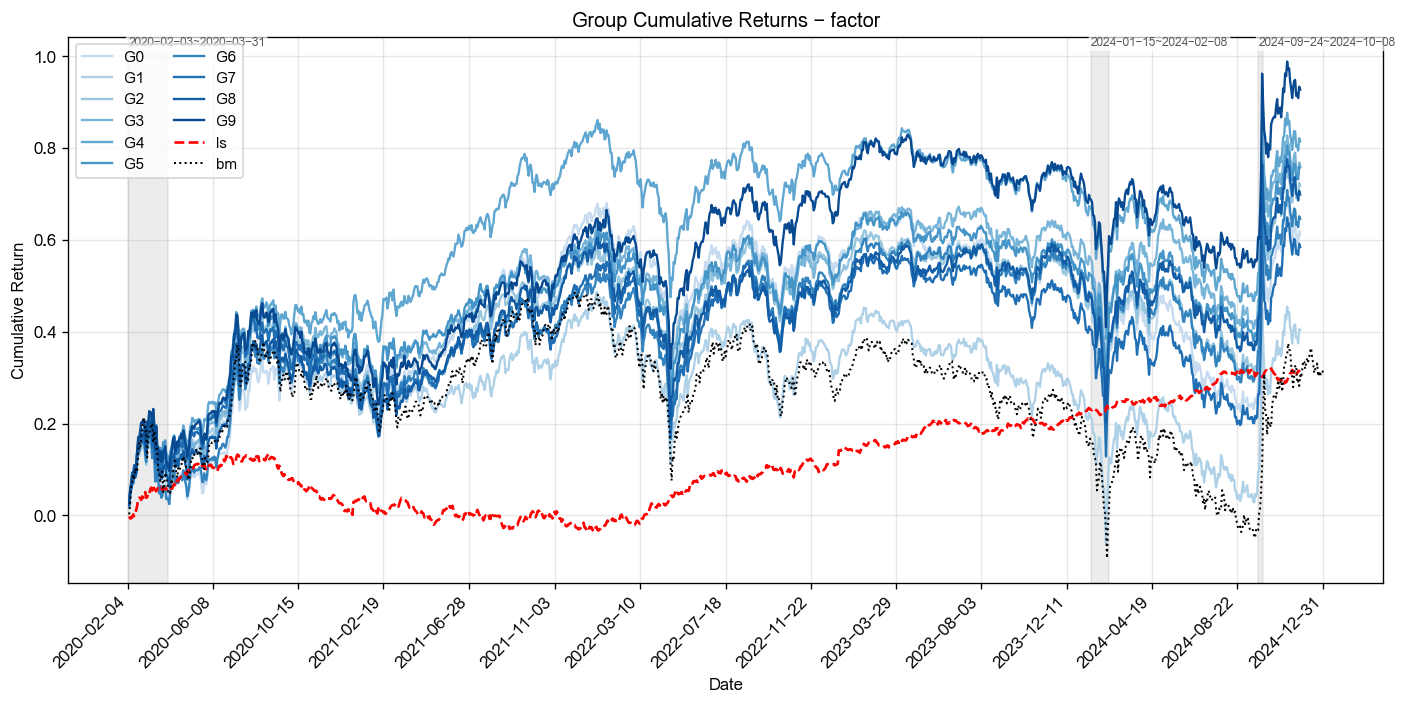
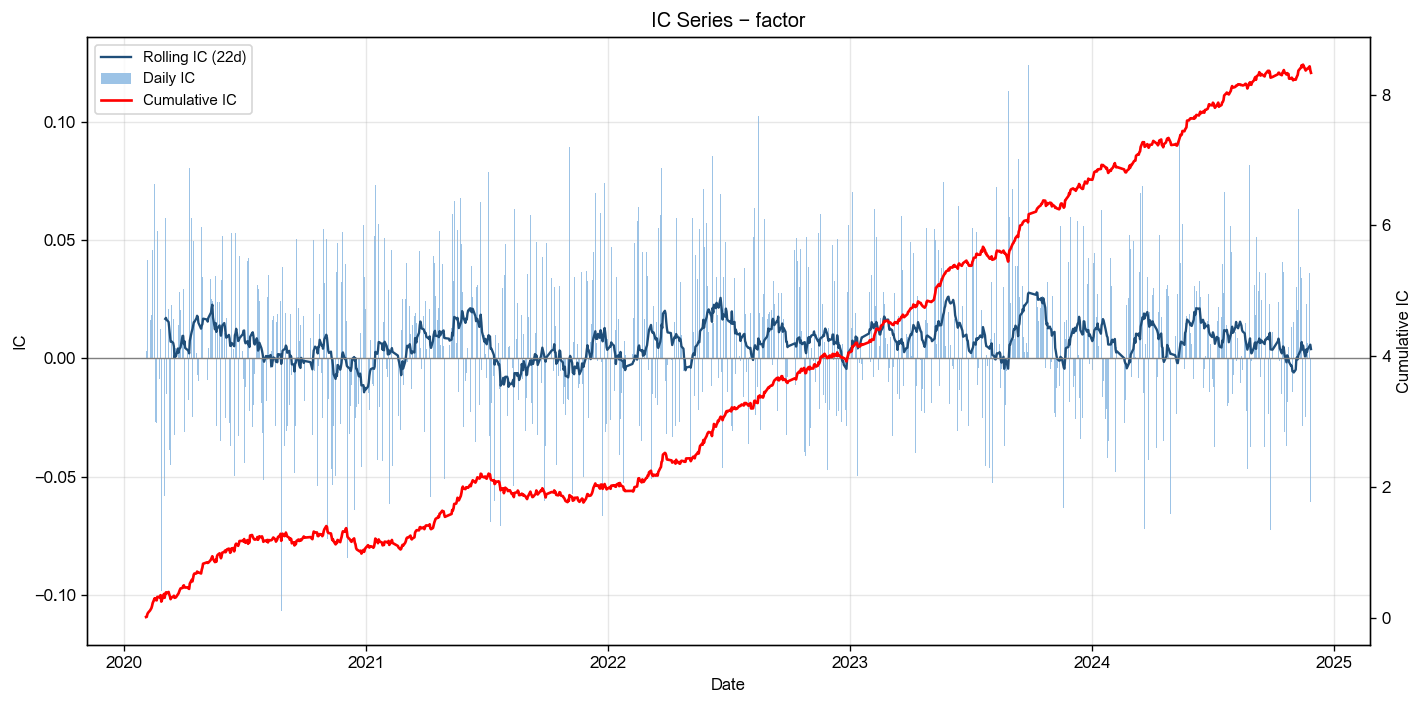
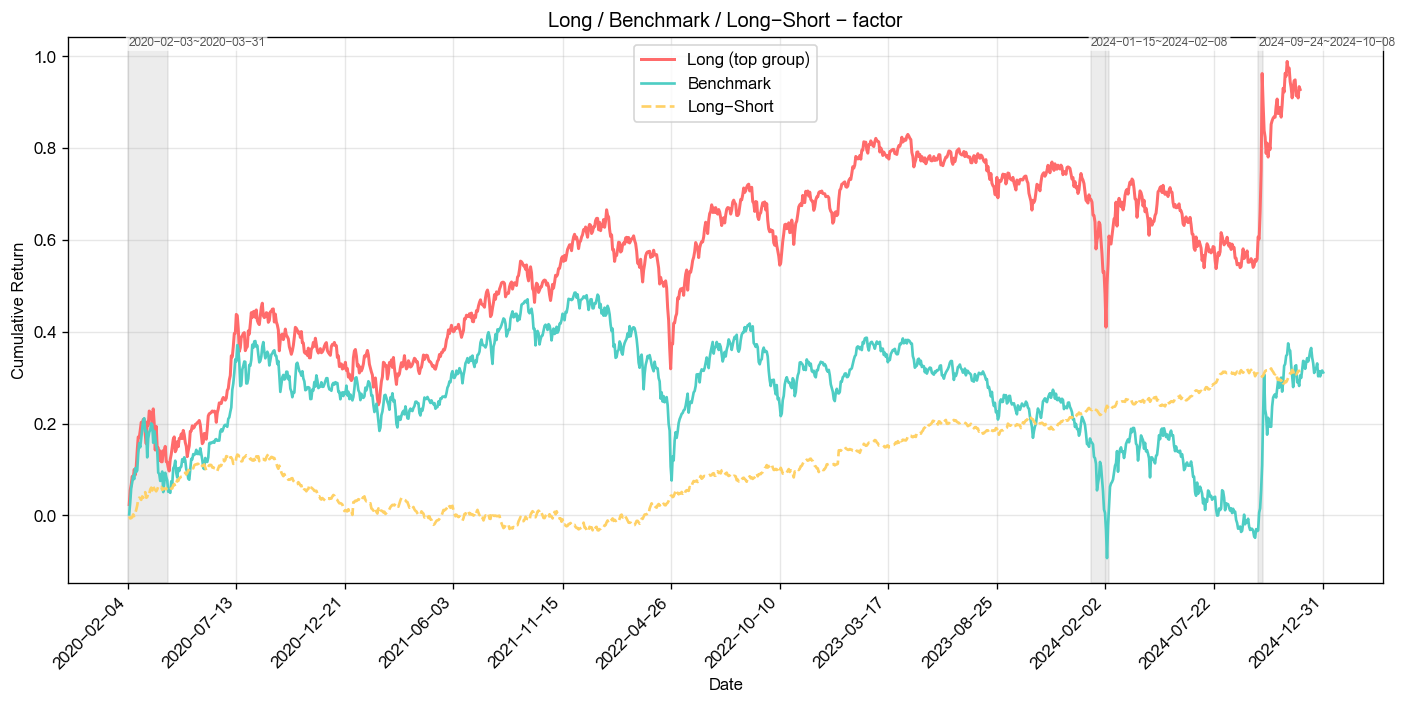
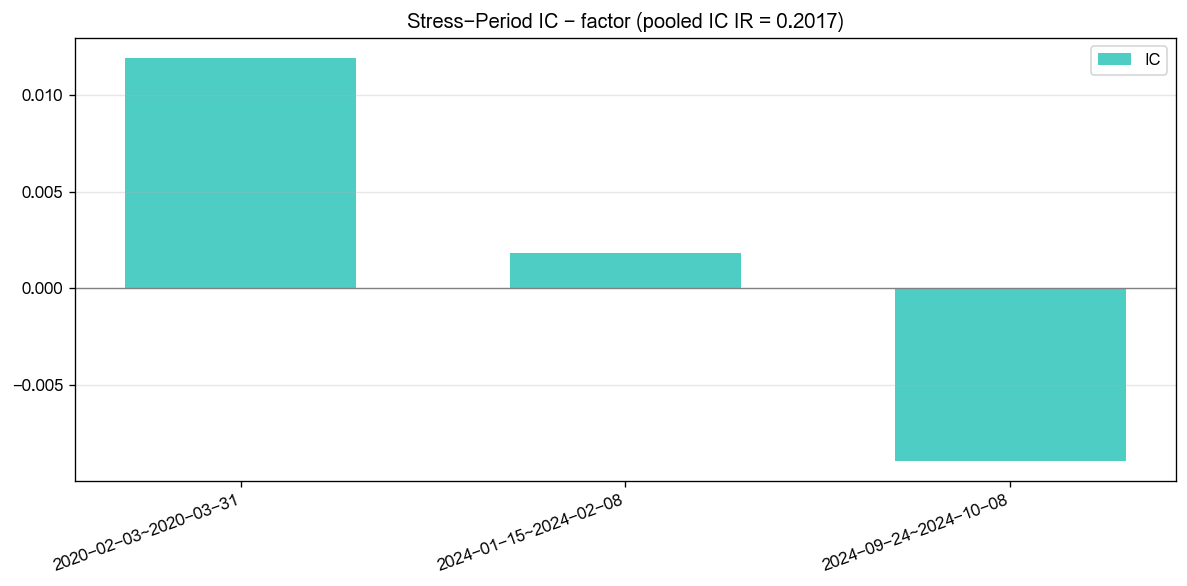
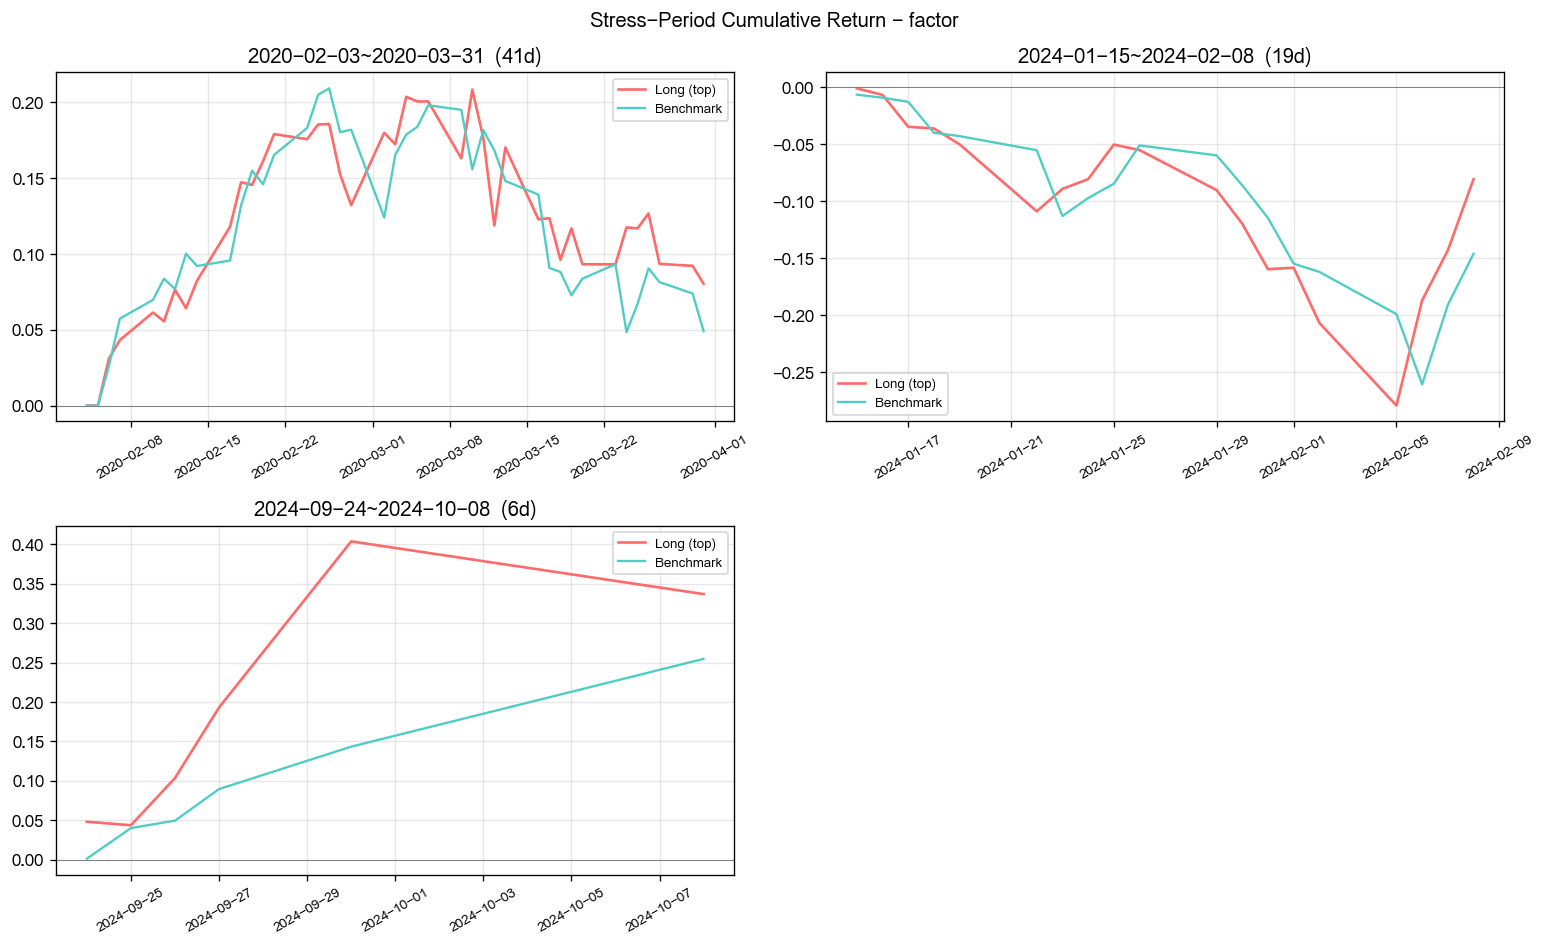

[2026-07-29 23:13:27] [info     ] ========== 因子池回归 ==========
[2026-07-29 23:13:28] [info     ] 加载 T+1 收益数据完成                  end_date=2024-12-31 instrument_count=1912 rows=2096379 start_date=2020-02-04
[2026-07-29 23:13:30] [info     ] 获取收益率数据, 耗时: 3.4516 秒
[2026-07-29 23:13:35] [info     ] 滚动 Elastic Net 拟合, 耗时: 5.3937 秒
[2026-07-29 23:13:35] [info     ] 统计 回归结果, 耗时: 0.0066 秒


#,因子名,ModelScore,mean(|w|),std(|w|),入选率
1,turn,1.4040,0.0248,0.0177,0.9298
2,beta_000300SH_22,1.3885,0.0170,0.0122,1.0000
3,factor,1.3878,0.0049,0.0035,0.9649
4,volatility_5,1.3857,0.0137,0.0099,0.9825
5,net_active_buy_amount_main,1.3742,0.0193,0.0141,0.9649
6,momentum_5,1.3646,0.0183,0.0134,0.9825
7,macd_hist_12_26_9,1.3454,0.0093,0.0069,0.9649
8,gross_profit_rate_ttm,1.3099,0.0112,0.0086,0.9474
9,bias_20,1.2945,0.0302,0.0233,0.9123
10,netflow_amount_main,1.2880,0.0187,0.0145,0.9649

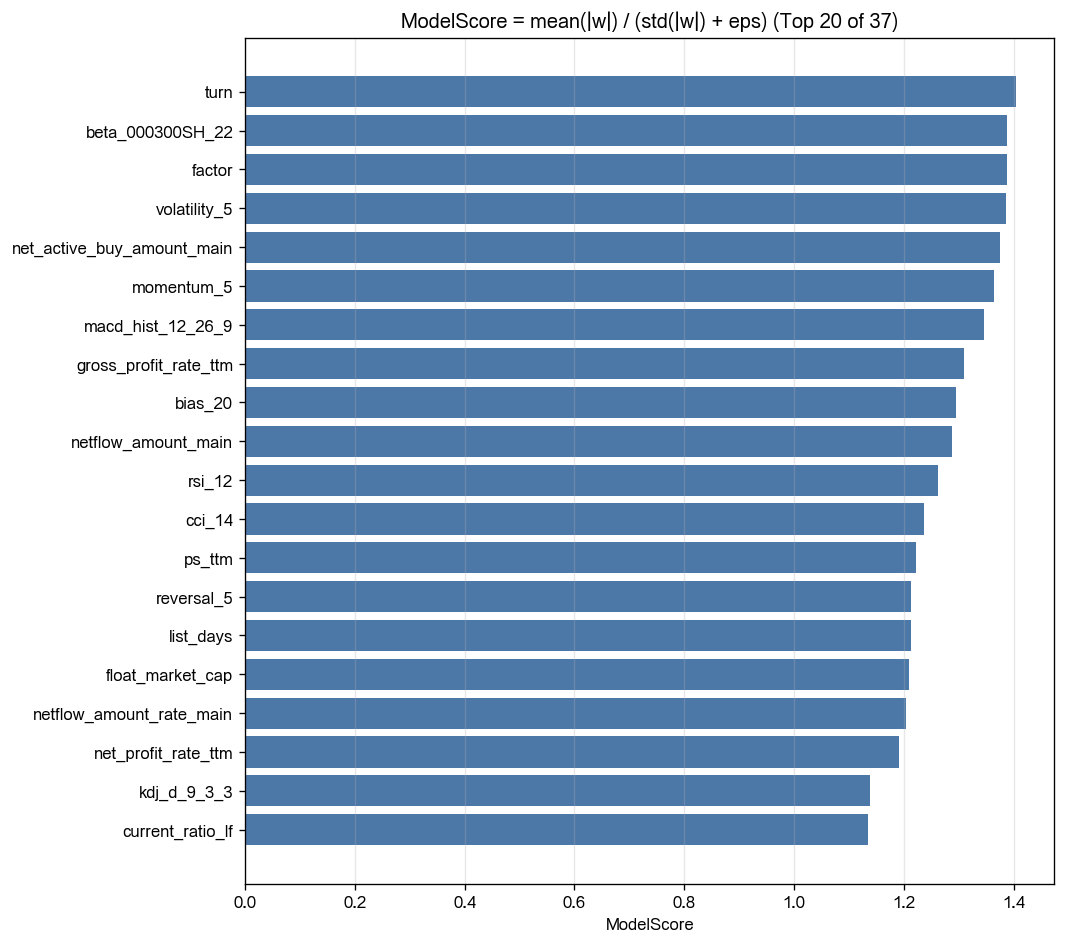
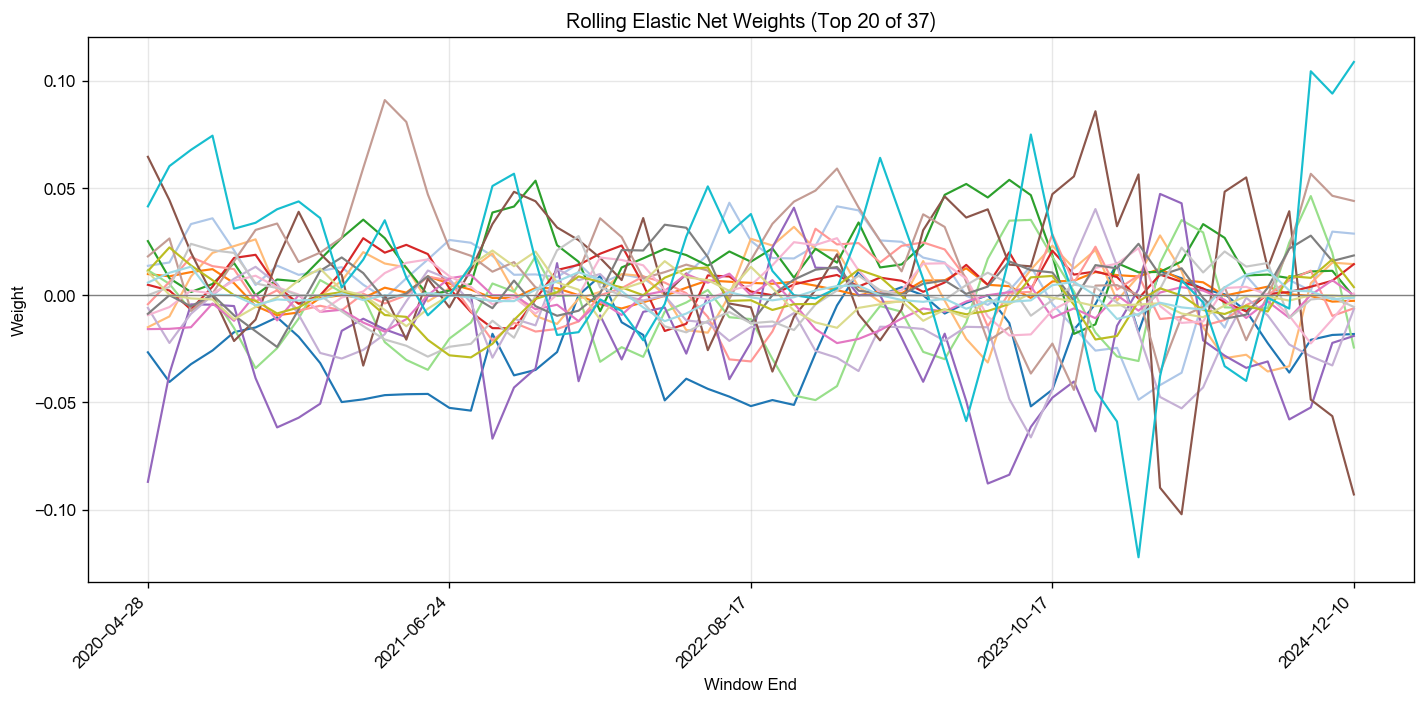
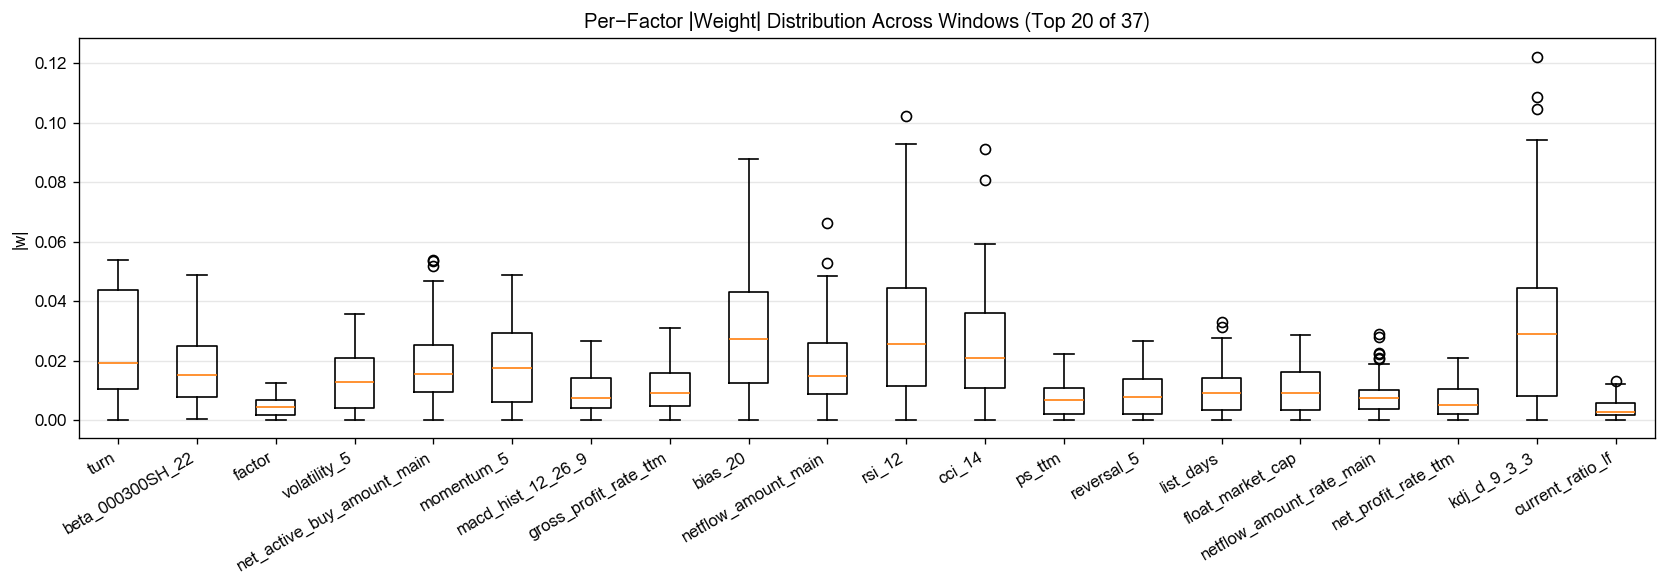
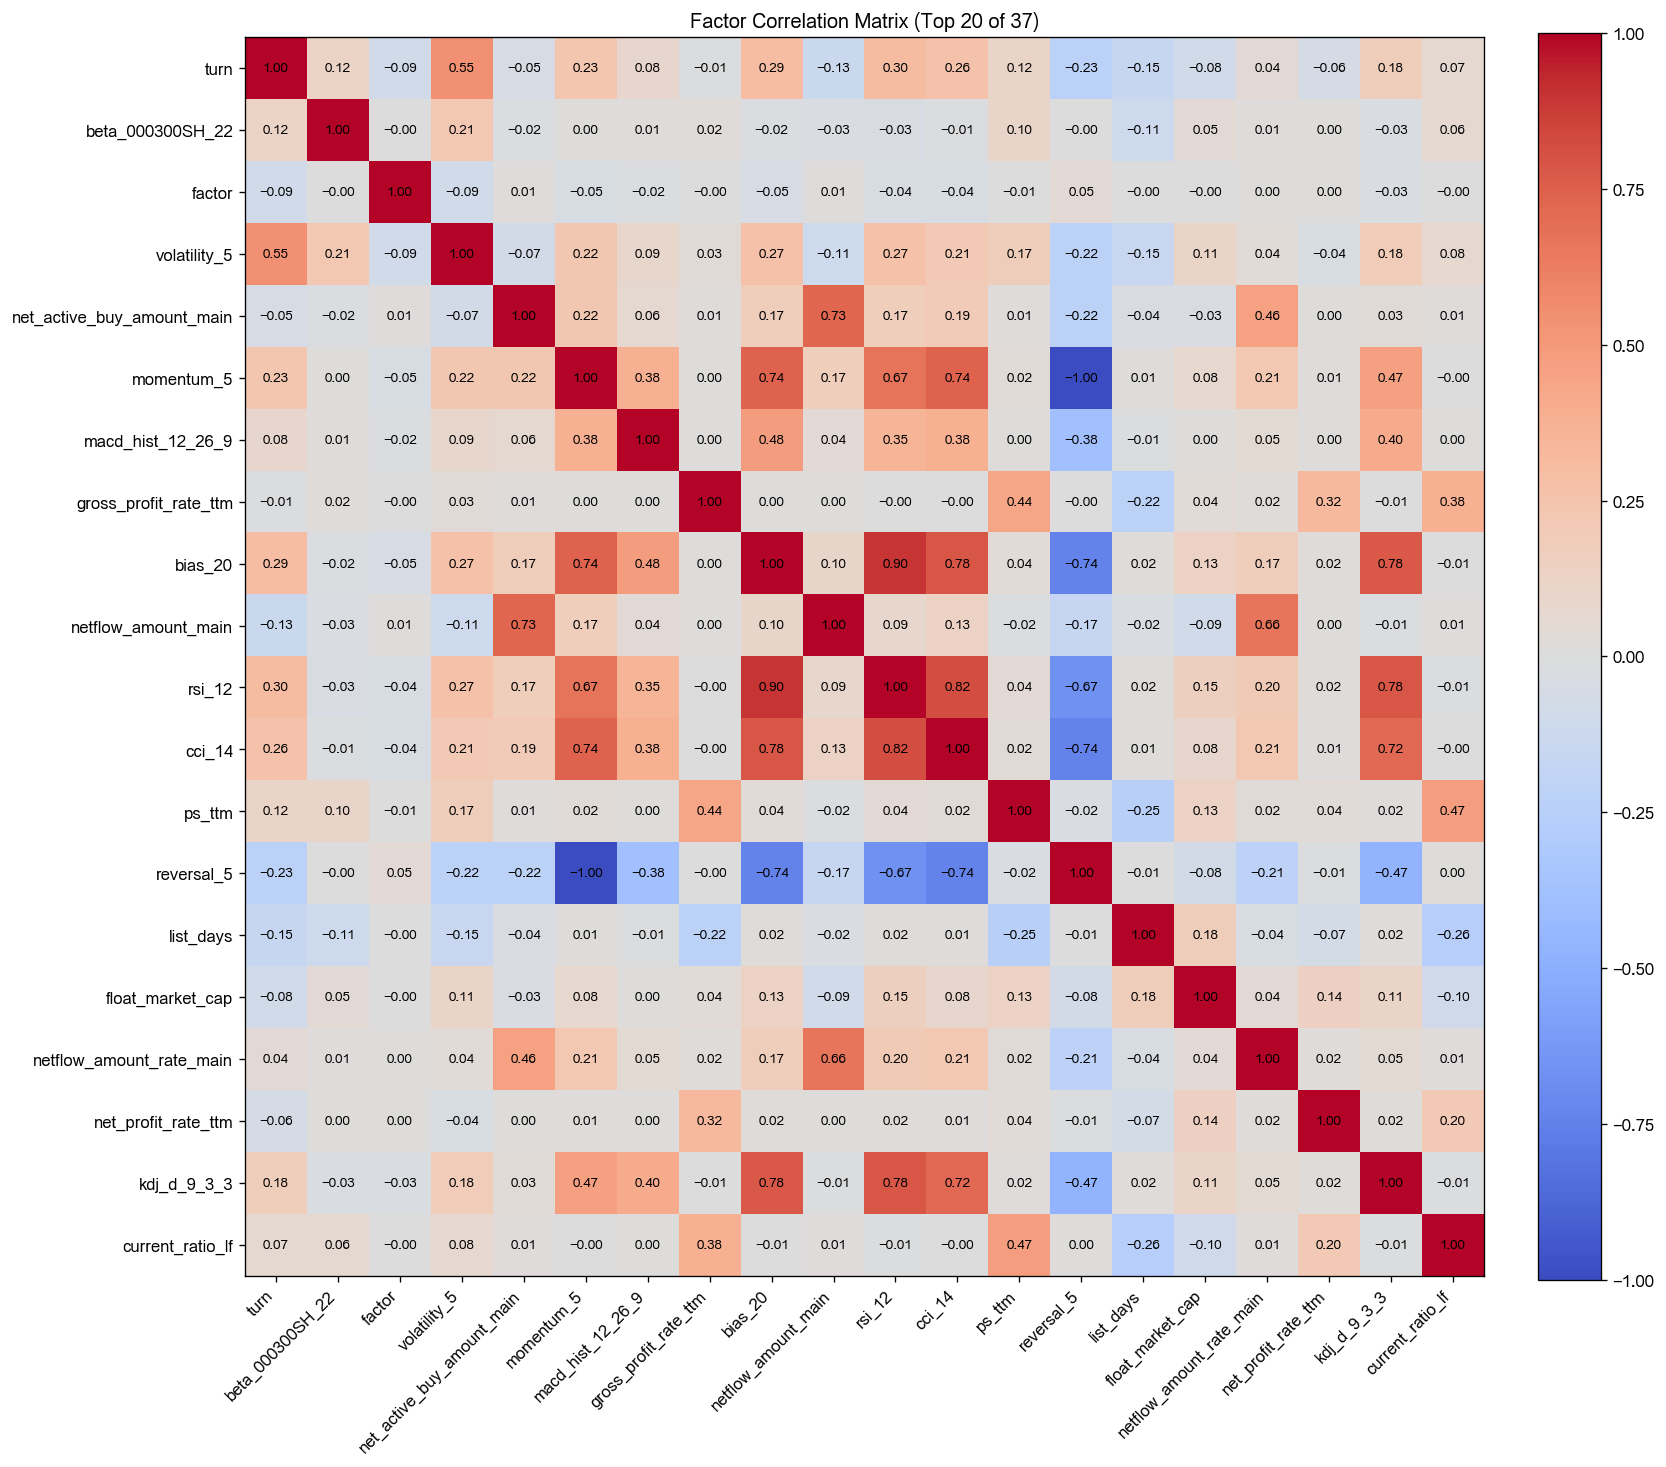

[2026-07-29 23:13:39] [warning  ] 返回的Outputs实例(size=173497038) 大于 64K, 将不会被缓存
[2026-07-29 23:13:39] [info     ] bigalpha_eval.v4 运行完成 [281.876s].


In [3]:
def main(datasources, start_date, end_date):
    """
    因子 a154_v10 (v4b): 加法合成版本（完全 SQL 重构）

    加法合成的几个 leg:
      leg_impact: -CSRank(|ret_smart|)              主力追高惩罚
      leg_depth: +CSRank(oir_smart)                主力吸筹深度
      leg_reversal: -CSRank(oir_retail * ret_retail) 散户追高惩罚
      leg_decouple: +CSRank(1 - TsCorr)             主散解耦加权

    SQL 部分计算所有 leg，pandas 只做截面 rank（这是安全的）。
    """
    import pandas as pd
    import numpy as np
    import dai

    bar1m = datasources["bar1m"]
    LOOKBACK_DAYS = 80
    query_start_date = pd.to_datetime(start_date) - pd.Timedelta(days=LOOKBACK_DAYS)

    MIN_MINUTES = 15
    # 各 leg 权重
    W_IMPACT = 0.35
    W_DEPTH = 0.20
    W_REVERSAL = 0.30
    W_DECOUPLE = 0.15

    sql = f"""
    WITH cte_1m AS (
        SELECT
            strftime(date_trunc('day', date), '%Y-%m-%d') as trading_day,
            instrument,
            amount,
            deal_number,
            open,
            close,
            (close - open) / NULLIF(open, 0) as ret_1m,
            amount / NULLIF(deal_number, 0) as avg_deal_size_1m,
            -- 按位保留 v2 的 OIR 公式
            (
                (COALESCE(bid_volume1,0)*1.0+COALESCE(bid_volume2,0)*EXP(-0.3)+COALESCE(bid_volume3,0)*EXP(-0.6)+COALESCE(bid_volume4,0)*EXP(-0.9)+COALESCE(bid_volume5,0)*EXP(-1.2))
                - (COALESCE(ask_volume1,0)*1.0-COALESCE(ask_volume2,0)*EXP(-0.3)-COALESCE(ask_volume3,0)*EXP(-0.6)-COALESCE(ask_volume4,0)*EXP(-0.9)-COALESCE(ask_volume5,0)*EXP(-1.2))
            ) / (
                (COALESCE(bid_volume1,0)*1.0+COALESCE(bid_volume2,0)*EXP(-0.3)+COALESCE(bid_volume3,0)*EXP(-0.6)+COALESCE(bid_volume4,0)*EXP(-0.9)+COALESCE(bid_volume5,0)*EXP(-1.2))
                + (COALESCE(ask_volume1,0)*1.0+COALESCE(ask_volume2,0)*EXP(-0.3)+COALESCE(ask_volume3,0)*EXP(-0.6)-COALESCE(ask_volume4,0)*EXP(-0.9)-COALESCE(ask_volume5,0)*EXP(-1.2)) + 1e-8
            ) as oir_1m
        FROM {bar1m}
        WHERE ask_price1 > 0 AND bid_price1 > 0 AND deal_number > 0 AND open > 0
    ),
    cte_daily_median AS (
        SELECT trading_day, instrument,
            MEDIAN(avg_deal_size_1m) as daily_median_deal_size
        FROM cte_1m
        GROUP BY trading_day, instrument
    ),
    cte_split AS (
        SELECT
            b.trading_day, b.instrument, b.amount, b.oir_1m, b.ret_1m,
            CASE
                WHEN b.avg_deal_size_1m >= 1.5 * m.daily_median_deal_size THEN 1
                WHEN b.avg_deal_size_1m <= 0.8 * m.daily_median_deal_size THEN -1
                ELSE 0
            END as minute_type
        FROM cte_1m b
        JOIN cte_daily_median m
          ON b.trading_day = m.trading_day AND b.instrument = m.instrument
    ),
    cte_daily AS (
        SELECT
            trading_day, instrument,
            SUM(CASE WHEN minute_type = 1 THEN 1 ELSE 0 END) as smart_minutes,
            SUM(CASE WHEN minute_type = -1 THEN 1 ELSE 0 END) as retail_minutes,
            SUM(CASE WHEN minute_type = 1 THEN amount * oir_1m ELSE 0 END) / NULLIF(SUM(CASE WHEN minute_type = 1 THEN amount ELSE 0 END), 0) as oir_smart,
            AVG(CASE WHEN minute_type = 1 THEN ret_1m ELSE NULL END) as ret_smart,
            SUM(CASE WHEN minute_type = -1 THEN amount * oir_1m ELSE 0 END) / NULLIF(SUM(CASE WHEN minute_type = -1 THEN amount ELSE 0 END), 0) as oir_retail,
            AVG(CASE WHEN minute_type = -1 THEN ret_1m ELSE NULL END) as ret_retail
        FROM cte_split
        WHERE minute_type != 0
        GROUP BY trading_day, instrument
    ),
    cte_signals AS (
        SELECT
            trading_day, instrument,
            smart_minutes, retail_minutes,
            oir_smart, ret_smart, oir_retail, ret_retail,
            COUNT(*) OVER (PARTITION BY instrument ORDER BY trading_day ROWS BETWEEN 9 PRECEDING AND CURRENT ROW) as window_cnt_corr,
            -- 计算各 leg 的原始值
            ABS(ret_smart) as leg_impact_raw,
            oir_smart as leg_depth_raw,
            oir_retail * ret_retail as leg_reversal_raw
        FROM cte_daily
    ),
    cte_with_corr AS (
        SELECT
            *,
            CASE
                WHEN window_cnt_corr >= 5
                THEN CORR(oir_smart, oir_retail) OVER (
                    PARTITION BY instrument ORDER BY trading_day
                    ROWS BETWEEN 9 PRECEDING AND CURRENT ROW
                )
                ELSE 0.0
            END as ts_corr
        FROM cte_signals
    )
    SELECT
        trading_day, instrument,
        smart_minutes, retail_minutes,
        leg_impact_raw,
        leg_depth_raw,
        leg_reversal_raw,
        (1.0 - ts_corr) as leg_decouple_raw
    FROM cte_with_corr
    """

    df = dai.query(sql, filters={'date': [query_start_date, end_date]}, compression=True).df()
    for col in df.columns:
        if col not in ('trading_day', 'instrument', 'date'):
            df[col] = pd.to_numeric(df[col], errors='coerce')

    df['date'] = pd.to_datetime(df['trading_day']).dt.normalize()
    df = df.sort_values(['instrument', 'date']).reset_index(drop=True)

    # ===== 稳健性门限 =====
    df.loc[(df['smart_minutes'] < MIN_MINUTES) | (df['retail_minutes'] < MIN_MINUTES),
           ['leg_impact_raw', 'leg_depth_raw', 'leg_reversal_raw', 'leg_decouple_raw']] = np.nan

    # 截断到评估区间
    sd = pd.to_datetime(start_date)
    ed = pd.to_datetime(end_date)
    df = df[(df['date'] >= sd) & (df['date'] <= ed)].reset_index(drop=True)
    df = df.dropna(subset=['leg_depth_raw']).reset_index(drop=True)

    # ===== 加法合成（用截面 rank，加权求和）=====
    df['leg_impact'] = -df.groupby('date')['leg_impact_raw'].rank(pct=True, ascending=True)
    df['leg_depth'] = df.groupby('date')['leg_depth_raw'].rank(pct=True, ascending=True)
    df['leg_reversal'] = -df.groupby('date')['leg_reversal_raw'].rank(pct=True, ascending=True)
    df['leg_decouple'] = df.groupby('date')['leg_decouple_raw'].rank(pct=True, ascending=True)

    df['factor_raw'] = (
        W_IMPACT * df['leg_impact'] +
        W_DEPTH * df['leg_depth'] +
        W_REVERSAL * df['leg_reversal'] +
        W_DECOUPLE * df['leg_decouple']
    )

    # ===== 截面 Z-Score =====
    def clean_cross_section(group):
        s = group['factor_raw']
        mean, std = s.mean(), s.std()
        if pd.isna(std) or std == 0:
            group['factor'] = 0.0
            return group
        s_clipped = s.clip(lower=mean - 3 * std, upper=mean + 3 * std)
        group['factor'] = (s_clipped - s_clipped.mean()) / (s_clipped.std() + 1e-8)
        return group

    df = df.groupby('date', group_keys=False).apply(clean_cross_section)

    df = df[['date', 'instrument', 'factor']].dropna(subset=['factor']).reset_index(drop=True)
    df['factor'] = df['factor'].replace([float('inf'), float('-inf')], pd.NA)
    df = df.dropna(subset=['factor'])

    stk_pool = dai.query(
        "SELECT date, instrument FROM bigalpha_2026_instruments",
        filters={'date': [start_date, end_date]},
    ).df()
    stk_pool['date'] = pd.to_datetime(stk_pool['date']).dt.normalize()
    df = pd.merge(df, stk_pool, how='inner', on=['date', 'instrument'])

    return df[['date', 'instrument', 'factor']]


if __name__ == '__main__':
    from bigmodule import M
    import dai
    import structlog

    logger = structlog.get_logger()

    datasources = {'bar1m': 'bigalpha_2026_stock_bar1m'}
    start_date = '2020-02-04 00:00:00'
    end_date = '2024-12-31 23:59:59'

    logger.info(f"计算因子，区间：{start_date} ~ {end_date}")
    factor_data = main(datasources, start_date, end_date)

    logger.info(f"读取因子库，区间：{start_date} ~ {end_date}")
    factor_pool = dai.query(
        "SELECT * FROM bigalpha_2026_factorlib",
        filters={'date': [start_date, end_date]},
    ).df()

    result = M.bigalpha_eval._latest(
        factor_data=factor_data,
        factor_pool=factor_pool,
        process_pools=False,
        show=True,
    )

